In [1]:
import numpy as np

import umbra
import batman
from transitleastsquares import grid

%matplotlib inline
import matplotlib.pyplot as plt

In [2]:
RNG = np.random.default_rng(5627323756)
MIN_IN_DAY = 24 * 60

In [3]:
# Observational parameters.
baseline = 90  # days
exp_time = 3./MIN_IN_DAY  # mins
exp_cadence = 5./MIN_IN_DAY  # mins

# Transit parameters.
ld_type = 'linear'
ld_pars = [0.6,]

period = 5.876
impact = 0.3
sma = umbra.density2axis(1.4, period)
inc = umbra.impact2inc(impact, sma, 0., 90.)

print(sma, inc)

params = batman.TransitParams()
params.t0 = 3.
params.per = 5.293
params.rp = 0.02
params.a = sma
params.inc = inc
params.ecc = 0.                     
params.w = 90.                        
params.limb_dark = ld_type
params.u = ld_pars

13.67155446773449 88.7426364995674


In [4]:
npoints = int(baseline/exp_cadence)  # 5 minute cadence
time = baseline*np.arange(npoints)/npoints + 100.

m = batman.TransitModel(params, time, exp_time=exp_time, supersample_factor=9)
transit = m.light_curve(params)

error = 500e-6
noise = RNG.normal(loc=0, scale=500e-6, size=npoints)

flux = transit + noise
flux_err = error*np.ones_like(flux)

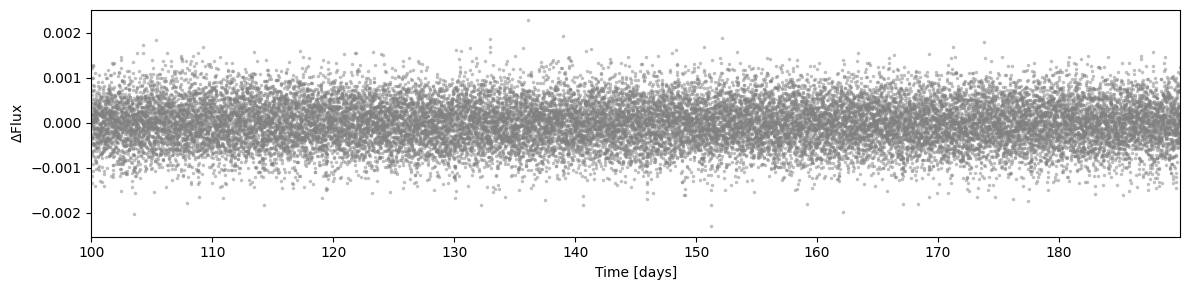

In [5]:
plt.figure(figsize=(12, 3))

ax = plt.subplot(111)

plt.plot(time, flux - 1, '.', markersize=5, markeredgecolor='None', alpha=0.5, color='gray')
plt.xlim(time[0], time[-1])

plt.xlabel('Time [days]')
plt.ylabel(r'$\Delta$Flux')

plt.tight_layout()

In [6]:
periods = grid.period_grid(1.0, 1.0, np.ptp(time))

In [7]:
search_result = umbra.transit_search(
    time,
    flux,
    flux_err,
    periods,
    exp_time,
    exp_cadence,
    R_star_min = 0.8,
    R_star_max = 1.2,
    M_star_min = 0.8,
    M_star_max = 1.2,
    ld_type=ld_type,
    ld_pars=ld_pars,
    normalisation='umbra',
    oversampling_duration=3,
    max_duty_cycle=0.15,
)

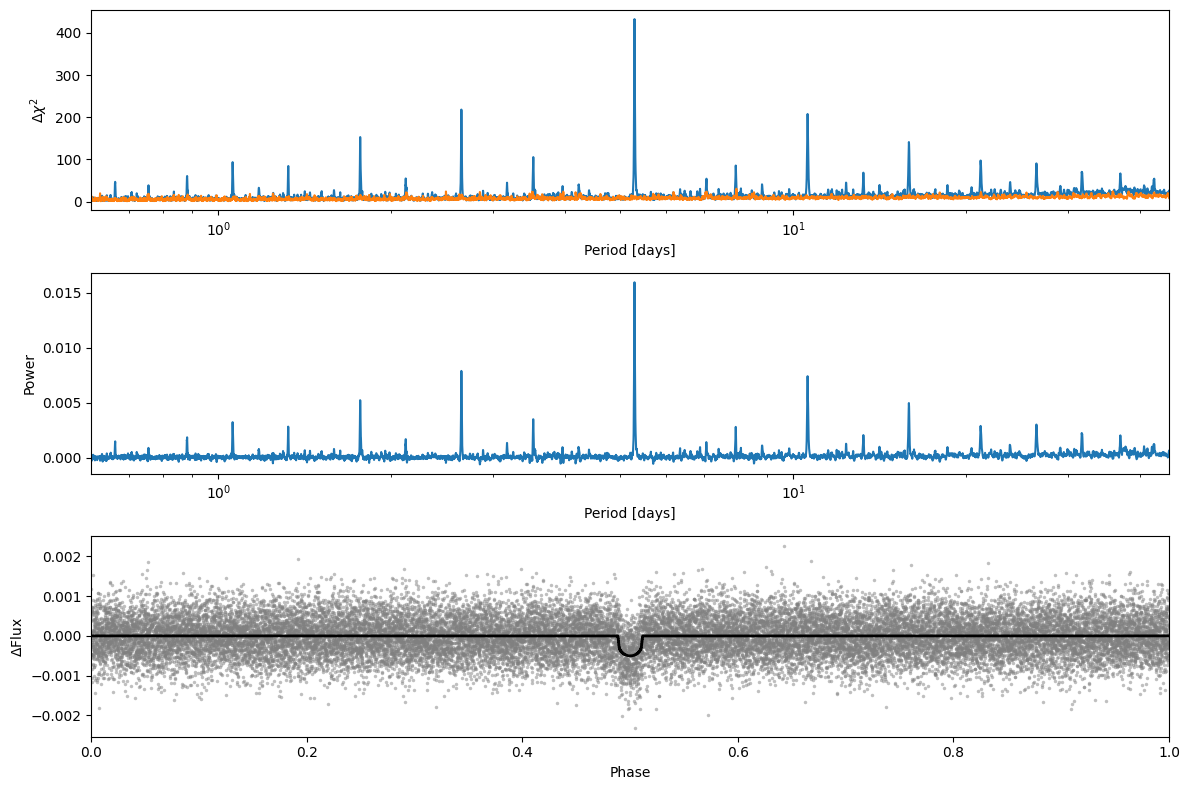

In [8]:
plt.figure(figsize=(12, 8))
    
ax = plt.subplot(311)

plt.semilogx(search_result.periods, search_result.dchisq_dec, label='dec')
plt.semilogx(search_result.periods, search_result.dchisq_inc, label='inc')

plt.xlabel('Period [days]')
plt.ylabel(r'$\Delta\chi^2$')

plt.subplot(312, sharex=ax)

plt.semilogx(search_result.periods, search_result.power)

plt.xlim(search_result.periods[0], search_result.periods[-1])

plt.xlabel('Period [days]')
plt.ylabel('Power')

plt.subplot(313)

sort = np.argsort(search_result.model_phase)
plt.plot(search_result.model_phase, flux - 1, '.', markersize=5, markeredgecolor='None', alpha=0.5, color='gray')
plt.plot(search_result.model_phase[sort], search_result.model_flux[sort] - 1, lw=2, color='k')

plt.xlim(0, 1)

plt.xlabel('Phase')
plt.ylabel(r'$\Delta$Flux')

plt.tight_layout()